# Предсказание цены автомобиля (Feedforward Neural Network)

**Датасет:** [Used Cars Price Prediction](https://www.kaggle.com/datasets/avikasliwal/used-cars-price-prediction) - 6019 автомобилей с индийского портала Cars24, 13 признаков
**Задача:** регрессия - предсказание цены подержанного автомобиля (в лакхах) по характеристикам

## 1. Краткая теория

**Feedforward нейросеть** для регрессии: архитектура аналогична классификации, но выходной слой - один нейрон без активации (линейный выход). Функция потерь - MSE вместо Cross-Entropy.

Каждый нейрон вычисляет: $z = \sum w_i x_i + b$, $a = \text{ReLU}(z)$. Выходной слой возвращает вещественное число:

$$\hat{y} = \mathbf{w}^T \mathbf{a}^{(L-1)} + b$$

Подробная теория - в [README.md](README.md).

## 2. Загрузка данных

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import kagglehub

path = kagglehub.dataset_download('avikasliwal/used-cars-price-prediction')
df = pd.read_csv(f'{path}/train-data.csv')

In [2]:
print(f'Размер: {df.shape[0]} записей, {df.shape[1]} столбцов')
df.head()

Размер: 6019 записей, 14 столбцов


,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         6019 non-null   int64  
 1   Name               6019 non-null   object 
 2   Location           6019 non-null   object 
 3   Year               6019 non-null   int64  
 4   Kilometers_Driven  6019 non-null   int64  
 5   Fuel_Type          6019 non-null   object 
 6   Transmission       6019 non-null   object 
 7   Owner_Type         6019 non-null   object 
 8   Mileage            6017 non-null   object 
 9   Engine             5983 non-null   object 
 10  Power              5983 non-null   object 
 11  Seats              5977 non-null   float64
 12  New_Price          824 non-null    object 
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 658.5+ KB


## 3. Первичный анализ

In [4]:
df.describe()

,Unnamed: 0,Year,Kilometers_Driven,Seats,Price
count,6019.000000,6019.000000,6.019000e+03,5977.000000,6019.000000
mean,3009.000000,2013.358199,5.873838e+04,5.278735,9.479468
std,1737.679967,3.269742,9.126884e+04,0.808840,11.187917
min,0.000000,1998.000000,1.710000e+02,0.000000,0.440000
25%,1504.500000,2011.000000,3.400000e+04,5.000000,3.500000
50%,3009.000000,2014.000000,5.300000e+04,5.000000,5.640000
75%,4513.500000,2016.000000,7.300000e+04,5.000000,9.950000
max,6018.000000,2019.000000,6.500000e+06,10.000000,160.000000


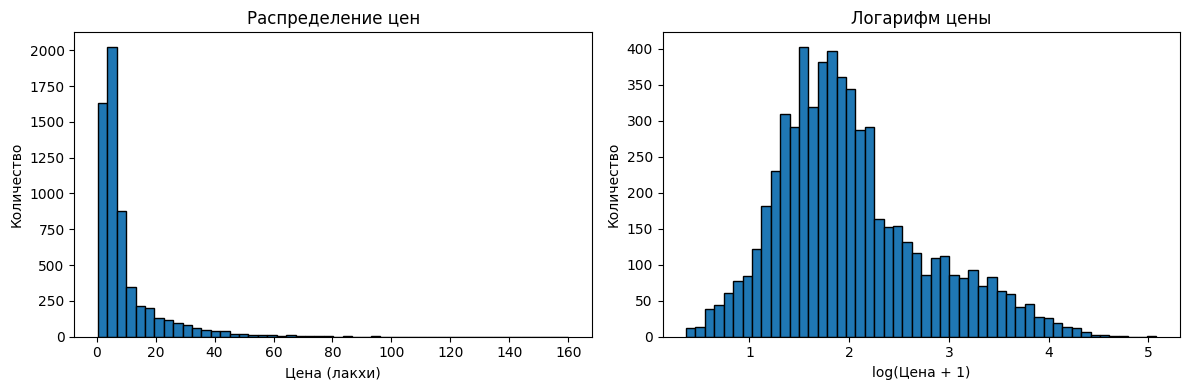

Медиана: 5.64, Среднее: 9.48, Макс: 160.00


In [5]:
# распределение целевой переменной
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Price'], bins=50, edgecolor='black')
axes[0].set_xlabel('Цена (лакхи)')
axes[0].set_ylabel('Количество')
axes[0].set_title('Распределение цен')

axes[1].hist(np.log1p(df['Price']), bins=50, edgecolor='black')
axes[1].set_xlabel('log(Цена + 1)')
axes[1].set_ylabel('Количество')
axes[1].set_title('Логарифм цены')

plt.tight_layout()
plt.show()

print(f'Медиана: {df["Price"].median():.2f}, Среднее: {df["Price"].mean():.2f}, Макс: {df["Price"].max():.2f}')

Распределение цен сильно скошено вправо: медиана 5.64 лакха, среднее 9.48, максимум 160. Логарифмирование приближает распределение к нормальному.

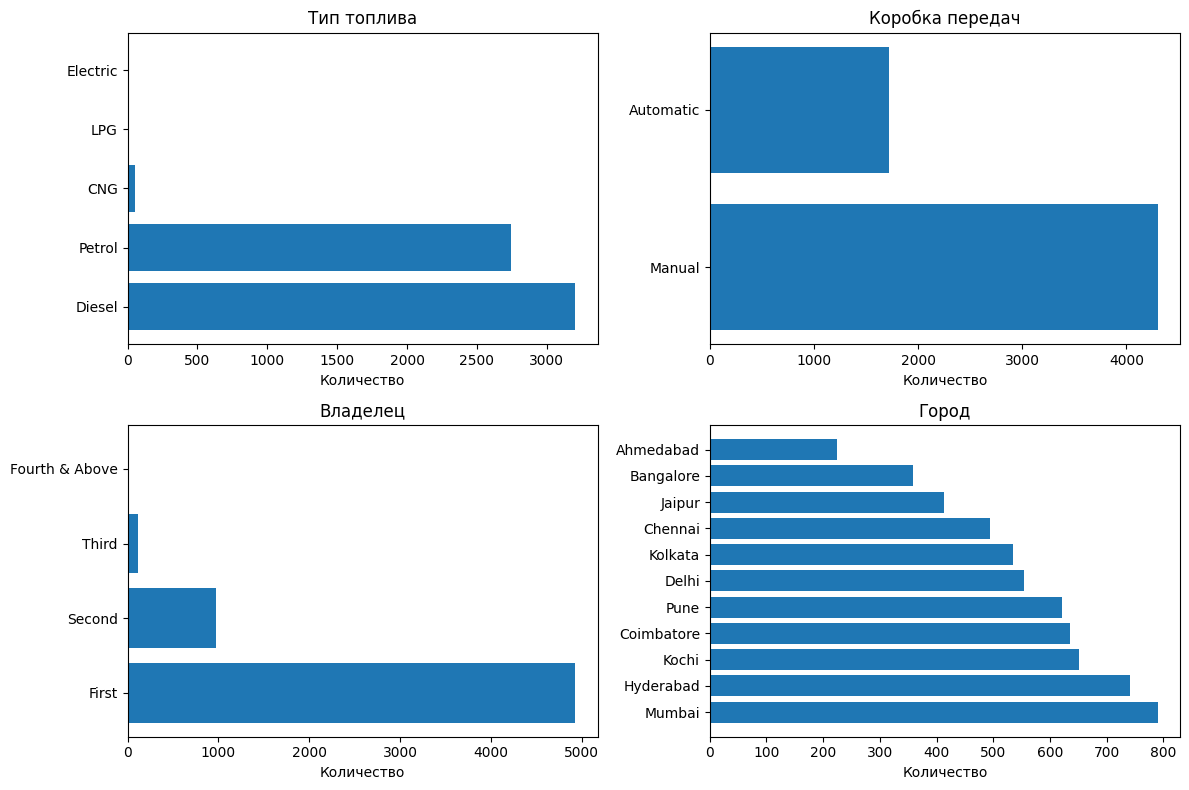

In [6]:
# распределение категориальных признаков
cat_cols = ['Fuel_Type', 'Transmission', 'Owner_Type', 'Location']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

titles = {'Fuel_Type': 'Тип топлива', 'Transmission': 'Коробка передач',
          'Owner_Type': 'Владелец', 'Location': 'Город'}

for ax, col in zip(axes.flat, cat_cols):
    counts = df[col].value_counts()
    ax.barh(counts.index, counts.values)
    ax.set_title(titles[col])
    ax.set_xlabel('Количество')

plt.tight_layout()
plt.show()

Дизель и бензин доминируют, механическая коробка преобладает над автоматической. Большинство автомобилей - от первого владельца.

In [7]:
# пропуски
nulls = df.isnull().sum()
print('Пропуски:')
print(nulls[nulls > 0])

Пропуски:
Mileage         2
Engine         36
Power          36
Seats          42
New_Price    5195
dtype: int64


## 4. Предобработка

In [8]:
# удаляем ненужные столбцы
df = df.drop(columns=['Unnamed: 0', 'New_Price', 'Name'])

# извлекаем числа из строковых признаков
df['Mileage'] = df['Mileage'].str.extract(r'([\d.]+)').astype(float)
df['Engine'] = df['Engine'].str.extract(r'([\d.]+)').astype(float)
df['Power'] = df['Power'].str.extract(r'([\d.]+)').astype(float)

# возраст автомобиля вместо года выпуска
df['Age'] = 2024 - df['Year']
df = df.drop(columns=['Year'])

print(f'До очистки пропусков: {df.shape[0]}')
df = df.dropna()
print(f'После очистки: {df.shape[0]}')

# удаляем выбросы по пробегу (> 500 000 км)
df = df[df['Kilometers_Driven'] <= 500_000]
print(f'После удаления выбросов по пробегу: {df.shape[0]}')

df.head()

До очистки пропусков: 6019
После очистки: 5872
После удаления выбросов по пробегу: 5868


,Location,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Age
0,Mumbai,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75,14
1,Pune,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50,9
2,Chennai,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50,13
3,Chennai,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00,12
4,Coimbatore,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74,11


In [9]:
# кодирование категориальных признаков (one-hot)
df_encoded = pd.get_dummies(df, columns=['Location', 'Fuel_Type', 'Transmission', 'Owner_Type'], drop_first=True)

print(f'Признаков после кодирования: {df_encoded.shape[1] - 1}')
df_encoded.head()

Признаков после кодирования: 23


,Kilometers_Driven,Mileage,Engine,Power,Seats,Price,Age,Location_Bangalore,Location_Chennai,Location_Coimbatore,...,Location_Kolkata,Location_Mumbai,Location_Pune,Fuel_Type_Diesel,Fuel_Type_LPG,Fuel_Type_Petrol,Transmission_Manual,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third
0,72000,26.60,998.0,58.16,5.0,1.75,14,False,False,False,...,False,True,False,False,False,False,True,False,False,False
1,41000,19.67,1582.0,126.20,5.0,12.50,9,False,False,False,...,False,False,True,True,False,False,True,False,False,False
2,46000,18.20,1199.0,88.70,5.0,4.50,13,False,True,False,...,False,False,False,False,False,True,True,False,False,False
3,87000,20.77,1248.0,88.76,7.0,6.00,12,False,True,False,...,False,False,False,True,False,False,True,False,False,False
4,40670,15.20,1968.0,140.80,5.0,17.74,11,False,False,True,...,False,False,False,True,False,False,False,False,True,False


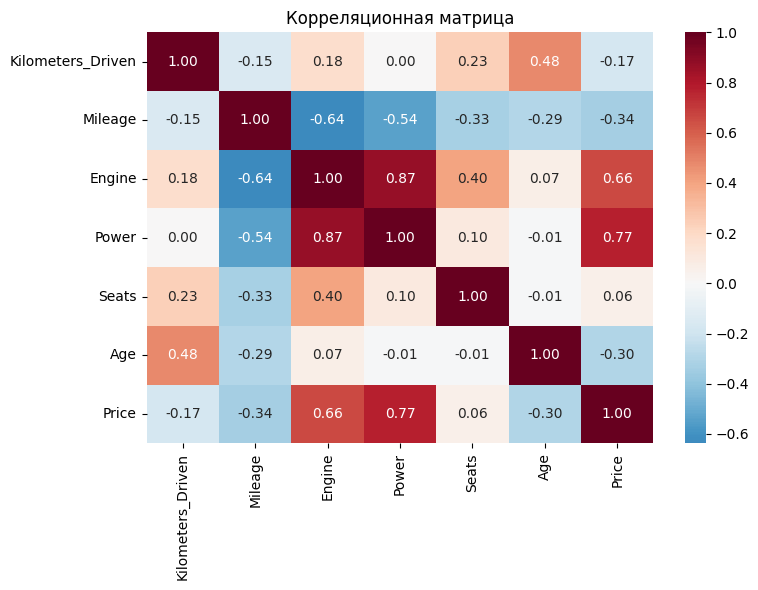

In [10]:
# корреляция числовых признаков с ценой
num_cols = ['Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Age', 'Price']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

Мощность (Power) имеет наибольшую положительную корреляцию с ценой. Возраст автомобиля отрицательно коррелирует с ценой. Пробег слабо связан с ценой напрямую.

In [11]:
# разбиение на признаки и целевую переменную
X = df_encoded.drop(columns=['Price']).values.astype(np.float32)
y = df_encoded['Price'].values.astype(np.float32)

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# масштабирование признаков
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

# масштабирование целевой переменной
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Признаков: {X_train.shape[1]}')

X_train: (4694, 23), X_test: (1174, 23)
Признаков: 23


In [12]:
# DataLoader
batch_size = 64

train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train_scaled, dtype=torch.float32)
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test_scaled, dtype=torch.float32)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Батчей: train={len(train_loader)}, test={len(test_loader)}')

Батчей: train=74, test=19


## 5. Обучение модели

### Baseline

In [13]:
input_dim = X_train.shape[1]

class CarPriceNet(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout=0.2):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_model(model, train_loader, test_loader, epochs=200, lr=1e-3, patience=20):
    """Обучение с early stopping."""
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    train_losses = []
    test_losses = []
    best_test_loss = float('inf')
    best_state = None
    no_improve = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * X_batch.size(0)
        train_losses.append(running_loss / len(train_loader.dataset))

        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                pred = model(X_batch)
                test_loss += criterion(pred, y_batch).item() * X_batch.size(0)
        test_losses.append(test_loss / len(test_loader.dataset))

        scheduler.step(test_losses[-1])

        if test_losses[-1] < best_test_loss:
            best_test_loss = test_losses[-1]
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping на эпохе {epoch + 1}')
                break

        if (epoch + 1) % 25 == 0:
            print(f'Epoch {epoch+1:3d}  train_loss={train_losses[-1]:.4f}  test_loss={test_losses[-1]:.4f}')

    model.load_state_dict(best_state)
    return train_losses, test_losses

In [14]:
# baseline: 2 скрытых слоя
torch.manual_seed(42)
baseline = CarPriceNet(input_dim, hidden_dims=[64, 32], dropout=0.2)
print(baseline)
print(f'Параметров: {sum(p.numel() for p in baseline.parameters()):,}')

train_losses, test_losses = train_model(baseline, train_loader, test_loader, epochs=200, lr=1e-3)

CarPriceNet(
  (net): Sequential(
    (0): Linear(in_features=23, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)
Параметров: 3,841


Epoch  25  train_loss=0.1832  test_loss=0.0905


Epoch  50  train_loss=0.1630  test_loss=0.0811


Epoch  75  train_loss=0.1602  test_loss=0.0744


Epoch 100  train_loss=0.1476  test_loss=0.0716


Epoch 125  train_loss=0.1409  test_loss=0.0715
Early stopping на эпохе 126


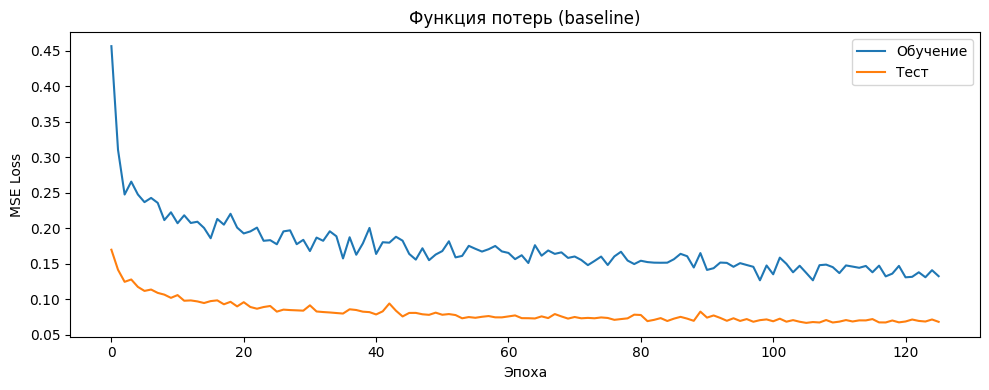

In [15]:
# графики обучения baseline
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Обучение')
ax.plot(test_losses, label='Тест')
ax.set_xlabel('Эпоха')
ax.set_ylabel('MSE Loss')
ax.set_title('Функция потерь (baseline)')
ax.legend()
plt.tight_layout()
plt.show()

Baseline (64-32) сошёлся на эпохе 126 (early stopping). Test loss стабилизировался на ~0.07, train loss ниже - лёгкое переобучение.

### Подбор гиперпараметров

Перебираем архитектуры с разной глубиной и шириной скрытых слоёв.

In [16]:
configs = [
    {'hidden_dims': [128, 64], 'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dims': [256, 128, 64], 'dropout': 0.2, 'lr': 1e-3},
    {'hidden_dims': [256, 128, 64], 'dropout': 0.3, 'lr': 5e-4},
    {'hidden_dims': [128, 64, 32], 'dropout': 0.1, 'lr': 1e-3},
]

results = []
for i, cfg in enumerate(configs):
    torch.manual_seed(42)
    model = CarPriceNet(input_dim, cfg['hidden_dims'], cfg['dropout'])
    n_params = sum(p.numel() for p in model.parameters())
    tr_losses, te_losses = train_model(
        model, train_loader, test_loader,
        epochs=300, lr=cfg['lr'], patience=30
    )

    model.eval()
    with torch.no_grad():
        y_pred_scaled = model(torch.tensor(X_test, dtype=torch.float32)).numpy()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        'config': str(cfg['hidden_dims']),
        'dropout': cfg['dropout'],
        'lr': cfg['lr'],
        'params': n_params,
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'model': model,
        'train_losses': tr_losses,
        'test_losses': te_losses
    })
    print(f'\nКонфиг {i+1}: {cfg["hidden_dims"]}  dropout={cfg["dropout"]}  '
          f'R2={r2:.4f}  MAE={mae:.2f}  RMSE={rmse:.2f}  params={n_params:,}\n')

results_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('model', 'train_losses', 'test_losses')} for r in results])
print(results_df.to_string(index=False))

Epoch  25  train_loss=0.1634  test_loss=0.0872


Epoch  50  train_loss=0.1515  test_loss=0.0762


Epoch  75  train_loss=0.1353  test_loss=0.0714


Epoch 100  train_loss=0.1347  test_loss=0.0698


Epoch 125  train_loss=0.1172  test_loss=0.0693


...

Epoch 100  train_loss=0.1445  test_loss=0.0766


Epoch 125  train_loss=0.1455  test_loss=0.0759


Early stopping на эпохе 145

Конфиг 3: [256, 128, 64]  dropout=0.3  R2=0.8978  MAE=1.65  RMSE=3.10  params=48,257



Epoch  25  train_loss=0.1616  test_loss=0.0818


Early stopping на эпохе 49

Конфиг 4: [128, 64, 32]  dropout=0.1  R2=0.8923  MAE=1.79  RMSE=3.19  params=13,889

        config  dropout     lr  params       R2      MAE     RMSE
     [128, 64]      0.2 0.0010   11777 0.903702 1.640715 3.012646
[256, 128, 64]      0.2 0.0010   48257 0.901422 1.609613 3.048108
[256, 128, 64]      0.3 0.0005   48257 0.897844 1.652596 3.102934
 [128, 64, 32]      0.1 0.0010   13889 0.892334 1.790262 3.185517


Лучший результат у конфигурации [128, 64] с R2=0.90 и MAE=1.64 лакха. Более глубокие сети ([256, 128, 64]) не дали прироста качества - данных недостаточно для обучения 48k параметров.

In [17]:
best_idx = max(range(len(results)), key=lambda i: results[i]['R2'])
best = results[best_idx]
model = best['model']

print(f'Лучшая конфигурация: {best["config"]}, dropout={best["dropout"]}, lr={best["lr"]}')
print(f'R2={best["R2"]:.4f}, MAE={best["MAE"]:.2f}, RMSE={best["RMSE"]:.2f}')

Лучшая конфигурация: [128, 64], dropout=0.2, lr=0.001
R2=0.9037, MAE=1.64, RMSE=3.01


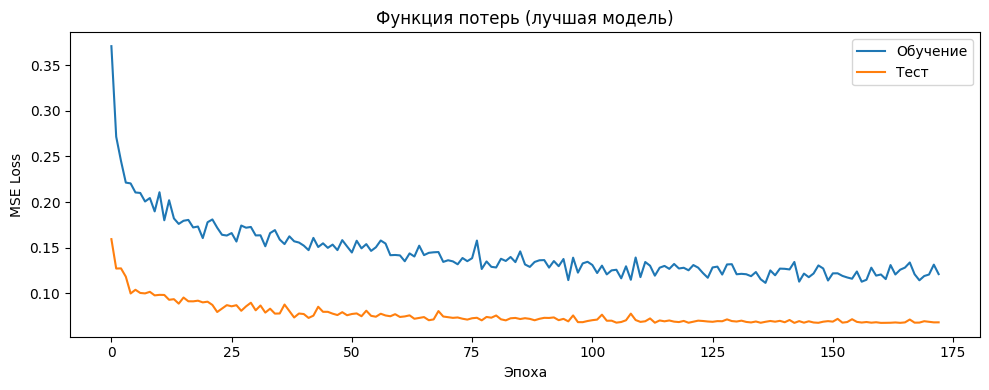

In [18]:
# графики обучения лучшей модели
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(best['train_losses'], label='Обучение')
ax.plot(best['test_losses'], label='Тест')
ax.set_xlabel('Эпоха')
ax.set_ylabel('MSE Loss')
ax.set_title('Функция потерь (лучшая модель)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Оценка качества

In [19]:
# предсказания лучшей модели
model.eval()
with torch.no_grad():
    y_pred_scaled = model(torch.tensor(X_test, dtype=torch.float32)).numpy()
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'R2:   {r2:.4f}')

RMSE: 3.0126
MAE:  1.6407
R2:   0.9037


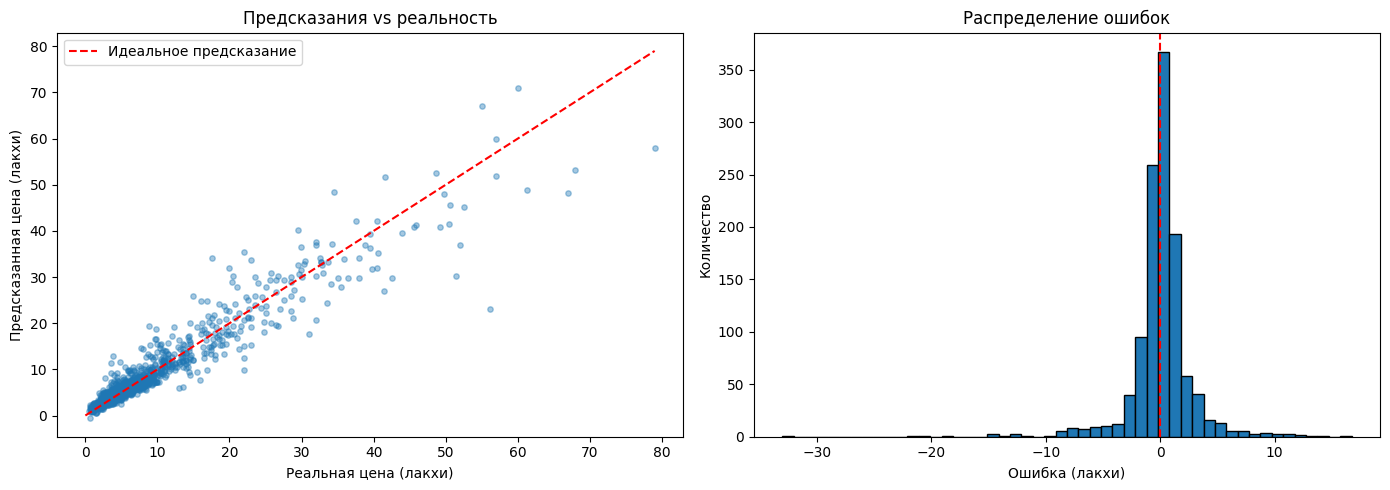

Средняя ошибка: 0.07, Медиана: 0.15


In [20]:
# предсказания vs реальность
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.4, s=15)
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', label='Идеальное предсказание')
axes[0].set_xlabel('Реальная цена (лакхи)')
axes[0].set_ylabel('Предсказанная цена (лакхи)')
axes[0].set_title('Предсказания vs реальность')
axes[0].legend()

errors = y_pred - y_test
axes[1].hist(errors, bins=50, edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_xlabel('Ошибка (лакхи)')
axes[1].set_ylabel('Количество')
axes[1].set_title('Распределение ошибок')

plt.tight_layout()
plt.show()

print(f'Средняя ошибка: {errors.mean():.2f}, Медиана: {np.median(errors):.2f}')

Модель хорошо предсказывает цены до 20 лакхов, но систематически занижает цены дорогих автомобилей. Средняя ошибка 0.07 лакха (близка к нулю), медиана 0.15 - смещение минимальное.

In [21]:
# ошибка по ценовым диапазонам
bins = [0, 5, 10, 20, 50, 200]
labels = ['0-5', '5-10', '10-20', '20-50', '50+']
price_bins = pd.cut(y_test, bins=bins, labels=labels)

errors_df = pd.DataFrame({'Реальная цена': y_test, 'Предсказание': y_pred,
                          'Абс. ошибка': np.abs(errors), 'Диапазон': price_bins})

summary = errors_df.groupby('Диапазон', observed=True).agg(
    Количество=('Реальная цена', 'count'),
    MAE=('Абс. ошибка', 'mean'),
    Медиана_ошибки=('Абс. ошибка', 'median')
).round(2)

print(summary)

          Количество    MAE  Медиана_ошибки
Диапазон                                   
0-5              522   0.82            0.57
5-10             375   1.17            0.85
10-20            161   2.53            1.89
20-50            102   4.58            3.58
50+               14  13.47           12.20


MAE растёт с ценовым диапазоном: 0.82 лакха для бюджетных авто (0-5), 4.58 для премиум (20-50), 13.47 для люкс (50+). Дорогих автомобилей в выборке всего 14 - модели не хватает примеров.

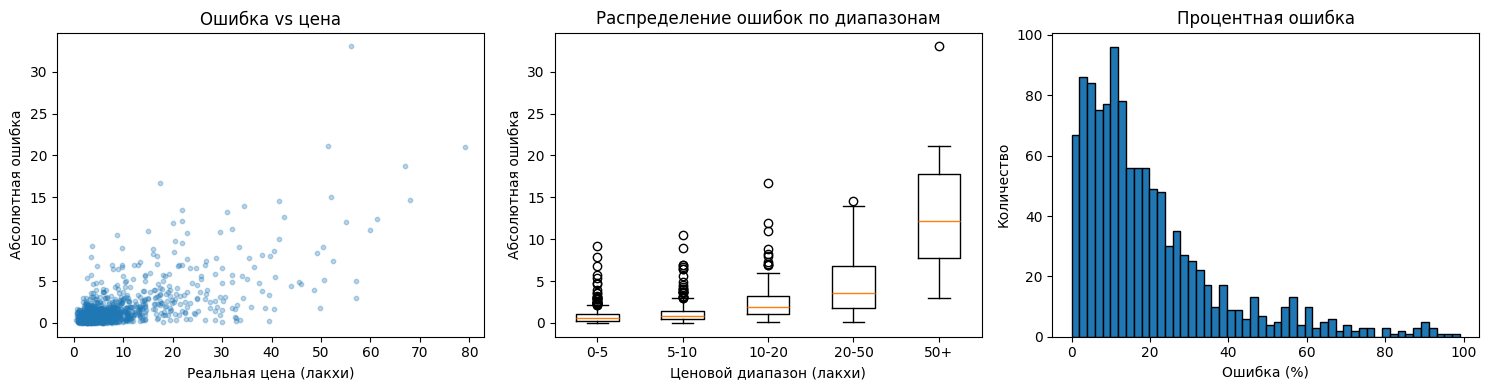

Медиана процентной ошибки: 14.7%


In [22]:
# анализ ошибок
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_test, np.abs(errors), alpha=0.3, s=10)
axes[0].set_xlabel('Реальная цена (лакхи)')
axes[0].set_ylabel('Абсолютная ошибка')
axes[0].set_title('Ошибка vs цена')

axes[1].boxplot([errors_df[errors_df['Диапазон'] == l]['Абс. ошибка'] for l in labels],
                labels=labels)
axes[1].set_xlabel('Ценовой диапазон (лакхи)')
axes[1].set_ylabel('Абсолютная ошибка')
axes[1].set_title('Распределение ошибок по диапазонам')

pct_error = np.abs(errors) / y_test * 100
axes[2].hist(pct_error[pct_error < 100], bins=50, edgecolor='black')
axes[2].set_xlabel('Ошибка (%)')
axes[2].set_ylabel('Количество')
axes[2].set_title('Процентная ошибка')

plt.tight_layout()
plt.show()

print(f'Медиана процентной ошибки: {np.median(pct_error):.1f}%')

Абсолютная ошибка растёт пропорционально цене. Медиана процентной ошибки 14.7% - типичная точность модели для автомобиля в середине ценового диапазона.